In [1]:
import itertools
import logging
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random

from modules import background_model, model, ModelDataSet, plotting, ProfileFindingSetup, SequenceRepresentation, utils

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

2025-08-07 17:07:56.123045: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 17:07:56.131686: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-07 17:07:56.147091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754579276.170224   14241 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754579276.176592   14241 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754579276.202300   14241 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
import tensorflow as tf
import tensorflow_text as tftext
print(tf.config.list_physical_devices('GPU'))

[]


2025-08-07 17:08:03.116616: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Old vs. New implementation

In [3]:
# fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/diluted_dataset/1.00/primary_sequences/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak.fasta")
# sim_fasta = Path("/home/ebelm/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/1.00/primary_sequences/wgEncodeAwgTfbsSIMULATED.fasta")

fasta = Path("/home/matthis/PhD/genomegraph/learn_specific_profiles/.brain_mnt/data/20250408_STREME_benchmark_revisited/diluted_dataset/1.00/primary_sequences/wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak.fasta")
sim_fasta = Path("/home/matthis/PhD/genomegraph/learn_specific_profiles/.brain_mnt/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/1.00/primary_sequences/wgEncodeAwgTfbsSIMULATED.fasta")

In [4]:
genomes = [SequenceRepresentation.Genome([seq]) for seq in SequenceRepresentation.loadFasta_agnostic(fasta)]

In [5]:
len(genomes)

51992

In [ ]:
data = ModelDataSet.ModelDataSet(genomes[:1000], ModelDataSet.DataMode.DNA, tile_size=100, tiles_per_X=1, batch_size=1, prefetch=3)

In [ ]:
bgmodel = background_model.TrainedQ(data, num_models=1, order=0, rand_seed=SEED)

In [ ]:
losses = bgmodel.train(lr=0.01, lr_factor=0.75, lr_patience=10, epochs=50)

In [ ]:
# plot losses
def plot_losses(name: str, losses: list[float]):
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

In [ ]:
plot_losses("new implementation", losses)

In [ ]:
bgmodel.getQ().numpy()[0]

In [ ]:
bgmodel.get_avg_Q()

In [ ]:
assert np.allclose(bgmodel.getQ().numpy()[0], bgmodel.get_avg_Q()), \
    f"Q matrix {bgmodel.getQ().numpy()[0]} and average Q {bgmodel.get_avg_Q()} do not match, diff: {bgmodel.getQ().numpy()[0] - bgmodel.get_avg_Q()}"

`Q` and `get_avg_Q` are the same for K=1 and order=0, as expected. Thus, a training with new and old implementation should be equivalent

In [ ]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

In [ ]:
setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=data,
    U=200, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = bgmodel,
)

In [ ]:
tf.config.run_functions_eagerly(True) # needed because otherwise bgmodel.get_avg_Q() will fail because the Tensor.numpy() method is prohibited

In [ ]:
legacy_model = model.SpecificProfile(setup, rand_seed=SEED)
legacy_model.legacy_Z = True

---

Debug this

In [6]:
tf.config.run_functions_eagerly(True) # needed because otherwise bgmodel.get_avg_Q() will fail because the Tensor.numpy() method is prohibited
# tf.data.experimental.enable_debug_mode()


In [7]:
dbg_seq = genomes[0].getSequenceStrings()[0][:17]  # Use a shorter sequence for debugging
dbg_seq

'GAAGCCTCGCCGGAACT'

In [8]:
dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)
print(dbg_bgmodel.getQ().numpy())

2025-08-07 17:08:39,599 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-08-07 17:08:39,637 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)


[[0.1345 0.3655 0.3655 0.1345]]


In [9]:
dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)

2025-08-07 17:08:39,891 - DEBUG - [model.__init__] >>> setting tf global seed to 42
/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-08-07 17:08:39.992830: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
Xfwd = utils.oneHot(dbg_seq, dbg_setup.data.alphabet)
Xrc = utils.oneHot(dbg_seq[::-1].translate(utils._rctbl), dbg_setup.data.alphabet)
X0 = np.stack([Xfwd, Xrc], axis=0, dtype=np.float32)  # shape
X1 = X0.copy()
X = np.stack([X0, X1], axis=0)
print(X.shape)

(2, 2, 17, 4)


In [13]:
# bring X to shape (B, ntiles, N=2, f=2, 12, 4) where B, ntiles are 1
X = X.reshape((1, 1, 2, 2, len(dbg_seq), 4))
print(X.shape)

(1, 1, 2, 2, 17, 4)


In [14]:
P = dbg_model.getP()
P.shape

TensorShape([12, 4, 1])

In [15]:
P

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[0.0334],
        [0.0004],
        [0.5407],
        [0.4255]],

       [[0.0001],
        [0.0031],
        [0.9384],
        [0.0584]],

       [[0.0081],
        [0.0008],
        [0.7961],
        [0.195 ]],

       [[0.0049],
        [0.9286],
        [0.0663],
        [0.0001]],

       [[0.0453],
        [0.0006],
        [0.9456],
        [0.0085]],

       [[0.0013],
        [0.0005],
        [0.9967],
        [0.0015]],

       [[0.0064],
        [0.0237],
        [0.8159],
        [0.154 ]],

       [[0.0004],
        [0.0011],
        [0.9986],
        [0.    ]],

       [[0.001 ],
        [0.0008],
        [0.2584],
        [0.7398]],

       [[0.0443],
        [0.0066],
        [0.007 ],
        [0.9421]],

       [[0.4237],
        [0.5173],
        [0.0041],
        [0.0549]],

       [[0.0161],
        [0.0657],
        [0.8937],
        [0.0246]]], dtype=float32)>

In [14]:
Z_legacy, R_legacy = dbg_model.getZ_legacy(X, P)
Z_new = dbg_model.getZ(X, P)

In [15]:
assert Z_legacy.shape == Z_new.shape, f"Z_legacy shape {Z_legacy.shape} and Z_new shape {Z_new.shape} do not match"

In [16]:
Z_legacy[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [17]:
Z_new[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [18]:
assert np.allclose(Z_legacy, Z_new), f"Z_legacy {Z_legacy} and Z_new {Z_new} do not match, diff: {Z_legacy - Z_new}"

In [19]:
# what happens when Q differs?
dbg_bgmodel_2 = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel_2.Q_logit = tf.Variable(np.array([[1,0,0,1]], dtype=np.float32), trainable=True)
print(dbg_bgmodel_2.getQ().numpy())

dbg_setup_2 = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=5,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel_2,
)

dbg_model_2 = model.SpecificProfile(dbg_setup_2, rand_seed=SEED)

2025-07-21 17:41:22,010 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-21 17:41:22,024 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-07-21 17:41:22,040 - DEBUG - [model.__init__] >>> setting tf global seed to 42


[[0.3655 0.1345 0.1345 0.3655]]


2025-07-21 17:41:22.114758: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [20]:
P = dbg_model_2.getP()
Z_new_2 = dbg_model_2.getZ(X, P)

In [21]:
assert Z_new.shape == Z_new_2.shape, f"Z_legacy shape {Z_legacy.shape} and Z_new shape {Z_new.shape} do not match"

In [22]:
Z_new[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-33.3287],
        [-33.363 ],
        [-36.7088],
        [-36.7977],
        [-19.6611],
        [-33.9848]],

       [[-26.2701],
        [-14.6207],
        [-19.6947],
        [-27.902 ],
        [-26.8634],
        [-12.7178]]], dtype=float32)>

In [23]:
Z_new_2[0,0,0]

<tf.Tensor: shape=(2, 6, 1), dtype=float32, numpy=
array([[[-30.2662],
        [-30.3005],
        [-33.6463],
        [-33.7353],
        [-16.5986],
        [-30.9224]],

       [[-23.2076],
        [-11.5582],
        [-16.6322],
        [-24.8395],
        [-23.8009],
        [ -9.6553]]], dtype=float32)>

For tiny X, a single P and a single, 0-order Q, the old and new implementation yield the same Z, as desired. If Q 
changes, Z changes as well, as desired.

Check the loss and gradients, maybe there are differences there?

In [24]:
dbg_model_legacy = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True

2025-07-21 17:41:25,331 - DEBUG - [model.__init__] >>> setting tf global seed to 42


In [25]:
dbg_model.debug_mode = True
S, R, loss, grad = dbg_model.train_step(X)

2025-07-21 17:41:25,709 - DEBUG - [model.train_step] >>> loss: 4.512325763702393, score: -25.4355411529541, grad: [[[-0.0131]
  [-0.0861]
  [ 0.0333]
  [ 0.0293]]

 [[-0.1635]
  [-0.1036]
  [-0.0083]
  [-0.0545]]

 [[-0.0346]
  [-0.0736]
  [ 0.0419]
  [ 0.0184]]

 [[-0.029 ]
  [ 0.0584]
  [ 0.0144]
  [-0.0907]]

 [[-0.0089]
  [-0.0807]
  [ 0.0418]
  [-0.0368]]

 [[-0.0458]
  [-0.0622]
  [ 0.0647]
  [-0.0437]]

 [[-0.062 ]
  [-0.0402]
  [ 0.0187]
  [-0.0091]]

 [[-0.0059]
  [ 0.0119]
  [ 0.126 ]
  [-0.0605]]

 [[-0.0676]
  [-0.071 ]
  [ 0.0243]
  [ 0.0418]]

 [[-0.041 ]
  [-0.0728]
  [-0.0717]
  [ 0.0099]]

 [[ 0.0161]
  [ 0.0194]
  [-0.0611]
  [-0.018 ]]

 [[-0.0257]
  [-0.0022]
  [ 0.0413]
  [-0.0185]]]
2025-07-21 17:41:25,713 - DEBUG - [model.train_step] >>> P_logit: [[[ 1.212 ]
  [-3.1664]
  [-0.0044]
  [-0.2439]]

 [[-7.8106]
  [-4.2152]
  [ 1.5042]
  [-1.2715]]

 [[-0.0738]
  [-2.4187]
  [ 0.5113]
  [-0.8949]]

 [[ 0.2575]
  [ 1.5027]
  [-1.1359]
  [-3.4437]]

 [[ 1.4679]
  [-2.84

In [26]:
dbg_model_legacy.debug_mode = True
S_legacy, R_legacy, loss_legacy, grad_legacy = dbg_model_legacy.train_step(X)

2025-07-21 17:41:25,987 - DEBUG - [model.train_step] >>> loss: 4.512325763702393, score: -25.43553924560547, grad: [[[-0.0131]
  [-0.0861]
  [ 0.0333]
  [ 0.0293]]

 [[-0.1635]
  [-0.1036]
  [-0.0083]
  [-0.0545]]

 [[-0.0346]
  [-0.0736]
  [ 0.0419]
  [ 0.0184]]

 [[-0.029 ]
  [ 0.0584]
  [ 0.0144]
  [-0.0907]]

 [[-0.0089]
  [-0.0807]
  [ 0.0418]
  [-0.0368]]

 [[-0.0458]
  [-0.0622]
  [ 0.0647]
  [-0.0437]]

 [[-0.062 ]
  [-0.0402]
  [ 0.0187]
  [-0.0091]]

 [[-0.0059]
  [ 0.0119]
  [ 0.126 ]
  [-0.0605]]

 [[-0.0676]
  [-0.071 ]
  [ 0.0243]
  [ 0.0418]]

 [[-0.041 ]
  [-0.0728]
  [-0.0717]
  [ 0.0099]]

 [[ 0.0161]
  [ 0.0194]
  [-0.0611]
  [-0.018 ]]

 [[-0.0257]
  [-0.0022]
  [ 0.0413]
  [-0.0185]]]
2025-07-21 17:41:25,990 - DEBUG - [model.train_step] >>> P_logit: [[[ 1.212 ]
  [-3.1664]
  [-0.0044]
  [-0.2439]]

 [[-7.8106]
  [-4.2152]
  [ 1.5042]
  [-1.2715]]

 [[-0.0738]
  [-2.4187]
  [ 0.5113]
  [-0.8949]]

 [[ 0.2575]
  [ 1.5027]
  [-1.1359]
  [-3.4437]]

 [[ 1.4679]
  [-2.8

In [27]:
S

<tf.Tensor: shape=(1, 1, 2, 1), dtype=float32, numpy=
array([[[[-12.7178],
         [-12.7178]]]], dtype=float32)>

In [28]:
S_legacy

<tf.Tensor: shape=(1, 1, 2, 1), dtype=float32, numpy=
array([[[[-12.7178],
         [-12.7178]]]], dtype=float32)>

In [29]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=4.512325763702393>

In [30]:
loss_legacy

<tf.Tensor: shape=(), dtype=float32, numpy=4.512325763702393>

In [31]:
grad

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[-0.0131],
        [-0.0861],
        [ 0.0333],
        [ 0.0293]],

       [[-0.1635],
        [-0.1036],
        [-0.0083],
        [-0.0545]],

       [[-0.0346],
        [-0.0736],
        [ 0.0419],
        [ 0.0184]],

       [[-0.029 ],
        [ 0.0584],
        [ 0.0144],
        [-0.0907]],

       [[-0.0089],
        [-0.0807],
        [ 0.0418],
        [-0.0368]],

       [[-0.0458],
        [-0.0622],
        [ 0.0647],
        [-0.0437]],

       [[-0.062 ],
        [-0.0402],
        [ 0.0187],
        [-0.0091]],

       [[-0.0059],
        [ 0.0119],
        [ 0.126 ],
        [-0.0605]],

       [[-0.0676],
        [-0.071 ],
        [ 0.0243],
        [ 0.0418]],

       [[-0.041 ],
        [-0.0728],
        [-0.0717],
        [ 0.0099]],

       [[ 0.0161],
        [ 0.0194],
        [-0.0611],
        [-0.018 ]],

       [[-0.0257],
        [-0.0022],
        [ 0.0413],
        [-0.0185]]], dtype=float3

In [32]:
grad_legacy

<tf.Tensor: shape=(12, 4, 1), dtype=float32, numpy=
array([[[-0.0131],
        [-0.0861],
        [ 0.0333],
        [ 0.0293]],

       [[-0.1635],
        [-0.1036],
        [-0.0083],
        [-0.0545]],

       [[-0.0346],
        [-0.0736],
        [ 0.0419],
        [ 0.0184]],

       [[-0.029 ],
        [ 0.0584],
        [ 0.0144],
        [-0.0907]],

       [[-0.0089],
        [-0.0807],
        [ 0.0418],
        [-0.0368]],

       [[-0.0458],
        [-0.0622],
        [ 0.0647],
        [-0.0437]],

       [[-0.062 ],
        [-0.0402],
        [ 0.0187],
        [-0.0091]],

       [[-0.0059],
        [ 0.0119],
        [ 0.126 ],
        [-0.0605]],

       [[-0.0676],
        [-0.071 ],
        [ 0.0243],
        [ 0.0418]],

       [[-0.041 ],
        [-0.0728],
        [-0.0717],
        [ 0.0099]],

       [[ 0.0161],
        [ 0.0194],
        [-0.0611],
        [-0.018 ]],

       [[-0.0257],
        [-0.0022],
        [ 0.0413],
        [-0.0185]]], dtype=float3

This also is equal.

Try a small training run with both implementations, the resulting profiles should be the same, then.

In [41]:
import importlib
importlib.reload(model)

<module 'modules.model' from '/home/matthis/PhD/genomegraph/learn_specific_profiles/modules/model.py'>

In [39]:
dbg_seq = genomes[0].getSequenceStrings()[0]#[:17]  # Use a shorter sequence for debugging

dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_data_legacy = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1) # maybe using the same object for both models is the problem
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)

dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

dbg_setup_legacy = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data_legacy,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

dbg_setup.initializeProfiles_kmers(enforceU=True, minU=1)
dbg_setup_legacy.initializeProfiles_kmers(enforceU=True, minU=1)

tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model.debug_mode = True
dbg_model_legacy = model.SpecificProfile(dbg_setup_legacy, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True
dbg_model_legacy.debug_mode = True

2025-08-07 17:34:38,372 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-08-07 17:34:38,395 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-08-07 17:34:38,409 - INFO - [ProfileFindingSetup.ProfileFindingTrainingSetup.initializeProfiles] >>> Number of profiles: 1
2025-08-07 17:34:38,413 - WARNING - [ProfileFindingSetup.ProfileFindingTrainingSetup.initializeProfiles] >>> n_best_profiles (2) > number of profiles (1), setting n_best_profiles to 1
2025-08-07 17:34:38,415 - INFO - [ProfileFindingSetup.ProfileFindingTrainingSetup.initializeProfiles] >>> Number of profiles: 1
2025-08-07 17:34:38,418 - WARNING - [ProfileFindingSetup.ProfileFindingTrainingSetup.initializeProfiles] >>> n_best_profiles (2) > number of profiles (1), setting n_best_profiles to 1
2025-08-07 17:34:38,859 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-08-07 17:34:38,862 - DEBUG - [model.__init__] >>> Using initProfiles from training setup in

In [40]:
dbg_model_legacy.P_logit = tf.Variable(dbg_model.P_logit.numpy().copy(), trainable=True) # use same initial P in both models

In [41]:
assert np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy()), \
    f"P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} do not match, diff: {dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()}"

In [42]:
dbg_model.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[0.1345],
        [0.3655],
        [0.3655],
        [0.1345]],

       [[0.1345],
        [0.3655],
        [0.3655],
        [0.1345]]], dtype=float32)>

In [43]:
dbg_model_legacy.P_logit[:2]

<tf.Tensor: shape=(2, 4, 1), dtype=float32, numpy=
array([[[0.1345],
        [0.3655],
        [0.3655],
        [0.1345]],

       [[0.1345],
        [0.3655],
        [0.3655],
        [0.1345]]], dtype=float32)>

In [44]:
dbg_model.train()

2025-08-07 17:34:39,573 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0
2025-08-07 17:34:39,716 - DEBUG - [model.train_step] >>> loss: 0.9622926712036133, score: 1.2480800151824951, grad[0,:,0]: [0.0022 0.0061 0.0061 0.0022]
2025-08-07 17:34:39,721 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [-1.8627 -1.6334 -1.6334 -1.8627], P[0,:,0]: [0.2215 0.2785 0.2785 0.2215]
2025-08-07 17:34:40,010 - INFO - [model.train] >>> epoch 0 best profile 0 with mean loss 1.0885429382324219
2025-08-07 17:34:40,012 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 1.0885, max R: 0.000, min R: 0.000, time: 0.36s
2025-08-07 17:34:40,103 - DEBUG - [model.train_step] >>> loss: 1.0885429382324219, score: 1.267359972000122, grad[0,:,0]: [-0.031  -0.0272 -0.0272 -0.031 ]
2025-08-07 17:34:40,108 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [-0.4749 -0.4737 -0.4737 -0.4749], P[0,:,0]: [0.2499 0.2501 0.2501 0.2499]
2025-08-07 17:34:40.274758: I tensorflow/core/framework/loca

In [45]:
# dbg_model.P_logit[0,:,0]#[:2] # is reset to initial value after training, so no use in checking it

In [46]:
# dbg_model_legacy.P_logit[0,:,0]#[:2] # is reset to initial value after training, so no use in checking it

In [47]:
# assert not np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy()), \
#     f"P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} should not match!"

In [48]:
dbg_model_legacy.train()

2025-08-07 17:34:42,931 - DEBUG - [model.train.setLR] >>> Setting learning rate to 2.0


2025-08-07 17:34:43,033 - DEBUG - [model.train_step] >>> loss: 0.9622926712036133, score: 1.2480800151824951, grad[0,:,0]: [0.0022 0.0061 0.0061 0.0022]
2025-08-07 17:34:43,037 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [-1.8627 -1.6334 -1.6334 -1.8627], P[0,:,0]: [0.2215 0.2785 0.2785 0.2215]
2025-08-07 17:34:43,276 - INFO - [model.train] >>> epoch 0 best profile 0 with mean loss 1.0885426998138428
2025-08-07 17:34:43,278 - INFO - [model.train] >>> epoch     0 sum of profile tile losses = 1.0885, max R: 1.944, min R: -3.040, time: 0.26s
2025-08-07 17:34:43,355 - DEBUG - [model.train_step] >>> loss: 1.0885426998138428, score: 1.267359972000122, grad[0,:,0]: [-0.031  -0.0272 -0.0272 -0.031 ]
2025-08-07 17:34:43,359 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [-0.4749 -0.4737 -0.4737 -0.4749], P[0,:,0]: [0.2499 0.2501 0.2501 0.2499]
2025-08-07 17:34:43,573 - DEBUG - [model.train_step] >>> loss: -0.5903462767601013, score: 9.175880432128906, grad[0,:,0]: [-0.0079 -0.0079 -0.007

In [49]:
for i in range(len(dbg_model.profile_tracking.epoch)):
    print(f"Epoch {dbg_model.profile_tracking.epoch[i]}: Loss {dbg_model.profile_tracking.mean_losses[:,i]},\nScore {dbg_model.profile_tracking.max_scores[:,i]}")
    #plotting.plotLogo(dbg_model.profile_tracking.P[:,:,:,i], dbg_data.alphabet)

Epoch -1: Loss [0.9623],
Score [0.624]
Epoch 0: Loss [1.0885],
Score [0.6337]
Epoch 1: Loss [-0.5903],
Score [4.5879]
Epoch 2: Loss [-1.3091],
Score [5.5898]
Epoch 3: Loss [-1.2077],
Score [5.9465]
Epoch 4: Loss [-1.3437],
Score [5.9772]
Epoch 5: Loss [-1.5654],
Score [5.8706]
Epoch 6: Loss [-1.1959],
Score [5.4054]
Epoch 7: Loss [-0.1032],
Score [4.0216]
Epoch 8: Loss [-0.0174],
Score [3.8036]
Epoch 9: Loss [-0.5814],
Score [4.3515]


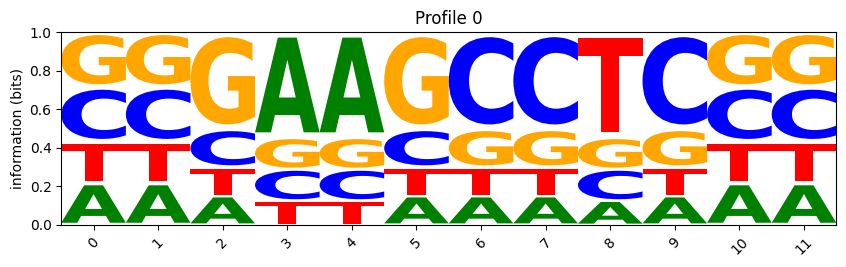

In [50]:
plotting.plotLogo(dbg_model.profile_report.P, dbg_setup.data.alphabet)

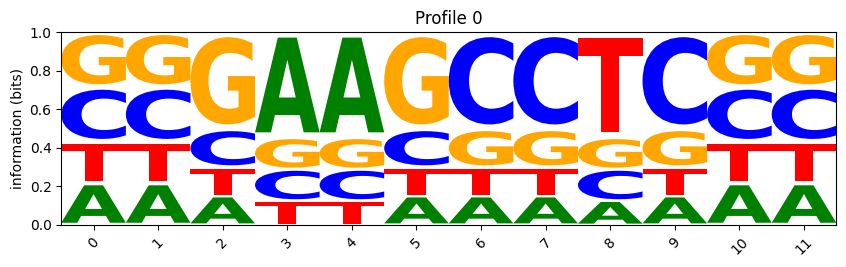

In [51]:
# ^^^ new implementation ^^^ || vvv legacy implementation vvv
plotting.plotLogo(dbg_model_legacy.profile_report.P, dbg_setup.data.alphabet)

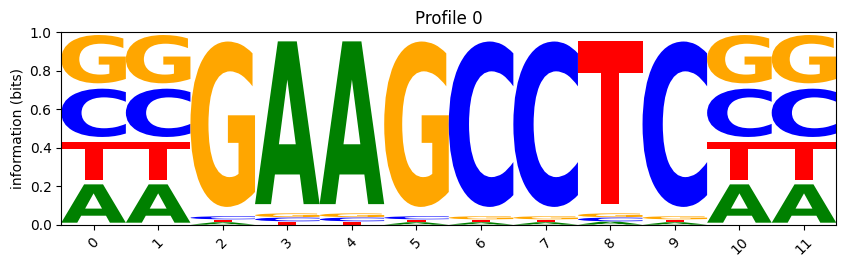

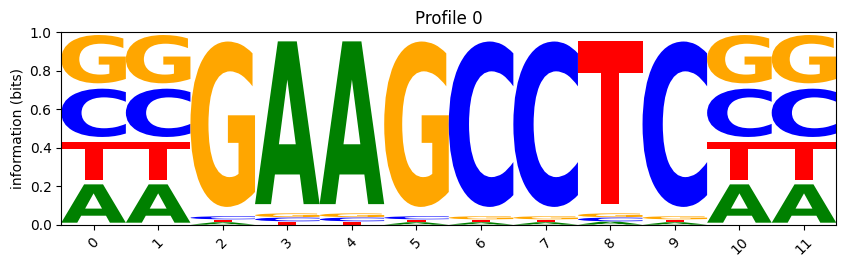

In [52]:
plotting.plotLogo(dbg_model.getP(), dbg_setup.data.alphabet)
plotting.plotLogo(dbg_model_legacy.getP(), dbg_setup.data.alphabet)

~~This is odd, Z, loss, gradients are the same for the same input, P and Q, but the model parameters are not the same 
after training.~~

This actually seems to be a floating point precision issue. When enabling debug mode, which cuts the floats of `Z` for
both implementations to the same (low) number of digits, the parameters are the same after training.

---

Next: do a step-by-step and side-by-side training manually, and track when the parameters diverge.

In [100]:
dbg_seq = genomes[0].getSequenceStrings()[0]#[:17]  # Use a shorter sequence for debugging

dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_data_legacy = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.array([[0,1,1,0]], dtype=np.float32), trainable=True)

dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

dbg_setup_legacy = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data_legacy,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)
dbg_model_legacy = model.SpecificProfile(dbg_setup_legacy, rand_seed=SEED)
dbg_model_legacy.legacy_Z = True

dbg_model.debug_mode = True
dbg_model_legacy.debug_mode = True

dbg_model_legacy.P_logit = tf.Variable(dbg_model.P_logit.numpy().copy(), trainable=True) # use same initial P in both models

2025-07-21 18:22:35,385 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-07-21 18:22:35,419 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)


2025-07-21 18:22:35,851 - DEBUG - [model.__init__] >>> setting tf global seed to 42
/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-07-21 18:22:35,978 - DEBUG - [model.__init__] >>> setting tf global seed to 42


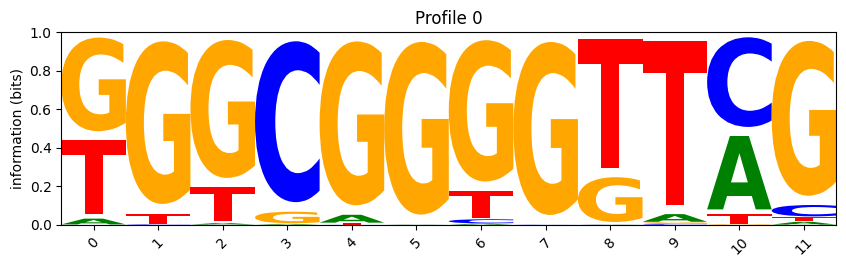

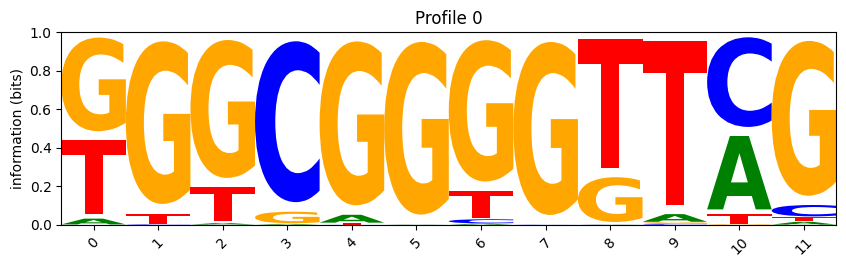

In [101]:
plotting.plotLogo(dbg_model.getP(), dbg_setup.data.alphabet)
plotting.plotLogo(dbg_model_legacy.getP(), dbg_setup.data.alphabet)

In [102]:
Xfwd = utils.oneHot(dbg_seq, dbg_setup.data.alphabet)
Xrc = utils.oneHot(dbg_seq[::-1].translate(utils._rctbl), dbg_setup.data.alphabet)
X0 = np.stack([Xfwd, Xrc], axis=0, dtype=np.float32)  # shape
X1 = X0.copy()
X = np.stack([X0, X1], axis=0)
X = X.reshape((1, 1, 2, 2, len(dbg_seq), 4)) # bring X to shape (B, ntiles, N=2, f=2, 12, 4) where B, ntiles are 1

In [103]:
ds = dbg_data.getDataset()
X_ds = next(iter(ds))[0]  # get the first batch from the dataset
print(X_ds.shape)

assert np.array_equal(X_ds.numpy(), X), "X_ds and X do not match"   

(1, 1, 2, 2, 100, 4)


/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [114]:
import numpy as np

for i in range(10):
    print(f"Epoch {i+1}")
    cont = True
    S, _, loss, grad = dbg_model.train_step(X)
    S_legacy, _, loss_legacy, grad_legacy = dbg_model_legacy.train_step(X)
    
    mean_loss = dbg_model.get_mean_losses(dbg_data.getDataset(withPosTracking=True), 
                                          dbg_model.getP(), dbg_model.P_logit)
    mean_loss_legacy = dbg_model_legacy.get_mean_losses(dbg_data.getDataset(withPosTracking=True), 
                                                        dbg_model_legacy.getP(), dbg_model_legacy.P_logit)
    
    # Compute the order of magnitude of the difference to scale it between 1 and 10
    def scale_to_1_10(arr):
        arr = np.abs(arr)
        max_val = np.max(arr)
        if max_val == 0:
            return np.zeros_like(arr), 0
        exponent = int(np.floor(np.log10(max_val)))
        factor = 10 ** (-exponent)
        scaled = arr * factor
        return scaled, factor

    S_diff = S.numpy() - S_legacy.numpy()
    S_diff_scaled, S_diff_factor = scale_to_1_10(S_diff)
    print(f"S_diff scaled: {S_diff_scaled[0,0,0,0]}, factor: {S_diff_factor}")
    loss_diff = loss.numpy() - loss_legacy.numpy()
    loss_diff_scaled, loss_diff_factor = scale_to_1_10(loss_diff)
    print(f"Loss_diff scaled: {loss_diff_scaled}, factor: {loss_diff_factor}")
    grad_diff = grad.numpy() - grad_legacy.numpy()
    grad_diff_scaled, grad_diff_factor = scale_to_1_10(grad_diff)
    print(f"Grad_diff scaled: {grad_diff_scaled[0,:,0]}, factor: {grad_diff_factor}")
    P_logit_diff = dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()
    P_logit_diff_scaled, P_logit_diff_factor = scale_to_1_10(P_logit_diff)
    print(f"P_logit_diff scaled: {P_logit_diff_scaled[0,:,0]}, factor: {P_logit_diff_factor}")
    P_diff = dbg_model.getP().numpy() - dbg_model_legacy.getP().numpy()
    P_diff_scaled, P_diff_factor = scale_to_1_10(P_diff)
    print(f"P_diff scaled: {P_diff_scaled[0,:,0]}, factor: {P_diff_factor}")
    mean_loss_diff = mean_loss.numpy() - mean_loss_legacy.numpy()
    mean_loss_diff_scaled, mean_loss_diff_factor = scale_to_1_10(mean_loss_diff)
    print(f"Mean Loss_diff scaled: {mean_loss_diff_scaled}, factor: {mean_loss_diff_factor}")
    print()
    
    
    # print(f"[epoch {i}] S {S.numpy()}, legacy S {S_legacy.numpy()}, diff: {S.numpy() - S_legacy.numpy()}")
    # print(f"[epoch {i}] Loss {loss.numpy()}, legacy Loss {loss_legacy.numpy()}, diff: {loss.numpy() - loss_legacy.numpy()}")
    # print(f"[epoch {i}] Grad {grad.numpy()}, legacy Grad {grad_legacy.numpy()}, diff: {grad.numpy() - grad_legacy.numpy()}")
    # print(f"[epoch {i}] P_logit {dbg_model.P_logit.numpy()}, legacy P_logit {dbg_model_legacy.P_logit.numpy()}, diff: {dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()}")
    # print(f"[epoch {i}] Mean Loss {mean_loss.numpy()}, legacy Mean Loss {mean_loss_legacy.numpy()}, diff: {mean_loss.numpy() - mean_loss_legacy.numpy()}")
    # for atol, abort in [(1e-3, True), (1e-6, False), (1e-10, False)]:
    #     diff = False
    #     if not np.allclose(S.numpy(), S_legacy.numpy(), atol=atol):
    #         if abort:
    #             print(f"[epoch {i}] S {S.numpy()} and legacy S {S_legacy.numpy()} do not match, diff: {S.numpy() - S_legacy.numpy()}")
    #             diff = True
    #         else:
    #             diff = True
    #     if not np.allclose(loss.numpy(), loss_legacy.numpy(), atol=atol):
    #         if abort:
    #             print(f"[epoch {i}] Loss {loss.numpy()} and legacy Loss {loss_legacy.numpy()} do not match, diff: {loss.numpy() - loss_legacy.numpy()}")
    #             diff = True
    #         else:
    #             diff = True
    #     if not np.allclose(grad.numpy(), grad_legacy.numpy(), atol=atol):
    #         if abort:
    #             print(f"[epoch {i}] Grad {grad.numpy()} and legacy Grad {grad_legacy.numpy()} do not match, diff: {grad.numpy() - grad_legacy.numpy()}")
    #             diff = True
    #         else:
    #             diff = True

    #     # check if P_logit is still the same
    #     if not np.allclose(dbg_model.P_logit.numpy(), dbg_model_legacy.P_logit.numpy(), atol=atol):
    #         if abort:
    #             print(f"[epoch {i}] P_logit {dbg_model.P_logit.numpy()} and legacy P_logit {dbg_model_legacy.P_logit.numpy()} do not match, diff: {dbg_model.P_logit.numpy() - dbg_model_legacy.P_logit.numpy()}")
    #             diff = True
    #         else:
    #             diff = True

    #     # check mean_losses
    #     if not np.allclose(mean_loss.numpy(), mean_loss_legacy.numpy(), atol=atol):
    #         if abort:
    #             print(f"[epoch {i}] Mean Loss {mean_loss.numpy()} and legacy Mean Loss {mean_loss_legacy.numpy()} do not match, diff: {mean_loss.numpy() - mean_loss_legacy.numpy()}")
    #             diff = True
    #         else:
    #             diff = True

    #     if diff:
    #         print(f"[epoch {i}] Parameters diverged with tolerance {atol}")
    #         if abort:
    #             cont = False

    # if not cont:            
    #     print("stopping training")
    #     break

2025-07-21 18:41:32,381 - DEBUG - [model.train_step] >>> loss: -16.12516975402832, score: 34.998443603515625, grad[0,:,0]: [-0.0148 -0.012   0.0072  0.0203]
2025-07-21 18:41:32,384 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9032 -1.3683 -0.9553 -0.6132], P[0,:,0]: [0.9392 0.0131 0.0198 0.0279]
2025-07-21 18:41:32,402 - DEBUG - [model.train_step] >>> loss: -16.125165939331055, score: 34.998435974121094, grad[0,:,0]: [-0.0148 -0.012   0.0072  0.0203]
2025-07-21 18:41:32,405 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9031 -1.3683 -0.9553 -0.6132], P[0,:,0]: [0.9392 0.0131 0.0198 0.0279]


Epoch 1
S_diff scaled: 3.814697265625, factor: 1000000
Loss_diff scaled: 3.814697265625, factor: 1000000
Grad_diff scaled: [2.6077 0.298  0.6147 0.4098], factor: 10000000
P_logit_diff scaled: [3.0994 1.4305 0.1192 0.    ], factor: 1000000
P_diff scaled: [2.3842 0.2142 0.5774 0.8009], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 2


2025-07-21 18:41:32,569 - DEBUG - [model.train_step] >>> loss: -16.136463165283203, score: 34.9572868347168, grad[0,:,0]: [-0.0124 -0.0097  0.0039  0.0177]
2025-07-21 18:41:32,571 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9395 -1.2106 -1.0575 -0.7533], P[0,:,0]: [0.9443 0.0149 0.0173 0.0235]
2025-07-21 18:41:32,589 - DEBUG - [model.train_step] >>> loss: -16.13646125793457, score: 34.95728302001953, grad[0,:,0]: [-0.0124 -0.0097  0.0039  0.0177]
2025-07-21 18:41:32,592 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9395 -1.2107 -1.0575 -0.7533], P[0,:,0]: [0.9443 0.0149 0.0173 0.0235]
2025-07-21 18:41:32,759 - DEBUG - [model.train_step] >>> loss: -16.14772605895996, score: 34.928619384765625, grad[0,:,0]: [-0.0068 -0.0053 -0.0003  0.011 ]
2025-07-21 18:41:32,762 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9936 -1.0185 -1.1492 -0.9335], P[0,:,0]: [0.9491 0.0172 0.0151 0.0187]
2025-07-21 18:41:32,778 - DEBUG - [model.train_step] >>> loss: -16.147724151611328, sco

S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 1.9073486328125, factor: 1000000
Grad_diff scaled: [3.1292 0.0466 0.5588 0.7451], factor: 10000000
P_logit_diff scaled: [2.1458 2.265  0.     0.596 ], factor: 1000000
P_diff scaled: [2.3842 0.0373 0.3725 0.596 ], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 3
S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 1.9073486328125, factor: 1000000
Grad_diff scaled: [2.9802 0.4377 0.3353 0.6612], factor: 10000000
P_logit_diff scaled: [0.4768 2.6226 0.2384 0.8345], factor: 1000000
P_diff scaled: [1.1921 0.3725 0.0931 0.298 ], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 4


2025-07-21 18:41:32,950 - DEBUG - [model.train_step] >>> loss: -16.151409149169922, score: 34.90054702758789, grad[0,:,0]: [-0.001   0.0002 -0.0041  0.0031]
2025-07-21 18:41:32,952 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.046  -0.8457 -1.2129 -1.1128], P[0,:,0]: [0.9522 0.0194 0.0135 0.0149]
2025-07-21 18:41:33,101 - DEBUG - [model.train_step] >>> loss: -16.14827537536621, score: 34.86984634399414, grad[0,:,0]: [ 0.003   0.0053 -0.0068 -0.0037]
2025-07-21 18:41:33,104 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.0842 -0.7388 -1.2379 -1.2577], P[0,:,0]: [0.9541 0.0209 0.0127 0.0124]
2025-07-21 18:41:33,121 - DEBUG - [model.train_step] >>> loss: -16.148273468017578, score: 34.869842529296875, grad[0,:,0]: [ 0.003   0.0053 -0.0068 -0.0037]
2025-07-21 18:41:33,124 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.0842 -0.7388 -1.2379 -1.2577], P[0,:,0]: [0.9541 0.0209 0.0127 0.0124]
2025-07-21 18:41:33,286 - DEBUG - [model.train_step] >>> loss: -16.146820068359375, s

...

S_diff scaled: 3.814697265625, factor: 1000000
Loss_diff scaled: 5.7220458984375, factor: 1000000
Grad_diff scaled: [0.7451 0.6147 0.3073 0.0931], factor: 10000000
P_logit_diff scaled: [1.9073 0.5364 0.596  0.7153], factor: 1000000
P_diff scaled: [1.1921 0.2794 0.2794 0.149 ], factor: 10000000
Mean Loss_diff scaled: [3.8147], factor: 1000000

Epoch 7
S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 3.814697265625, factor: 1000000
Grad_diff scaled: [1.4529 0.2049 0.3912 0.0466], factor: 10000000
P_logit_diff scaled: [1.6689 2.1458 0.4768 0.596 ], factor: 1000000
P_diff scaled: [0.     0.0931 0.2608 0.1583], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 8


2025-07-21 18:41:33,697 - DEBUG - [model.train_step] >>> loss: -16.166641235351562, score: 34.859092712402344, grad[0,:,0]: [ 0.0075  0.0064 -0.006  -0.0119]
2025-07-21 18:41:33,700 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.0637 -0.9175 -1.09   -1.3333], P[0,:,0]: [0.9554 0.0178 0.015  0.0118]
2025-07-21 18:41:33,919 - DEBUG - [model.train_step] >>> loss: -16.185070037841797, score: 34.889183044433594, grad[0,:,0]: [ 0.0065  0.0025 -0.0032 -0.0105]
2025-07-21 18:41:33,922 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.0143 -1.0558 -1.0027 -1.2454], P[0,:,0]: [0.9531 0.0163 0.0172 0.0135]
2025-07-21 18:41:33,940 - DEBUG - [model.train_step] >>> loss: -16.185068130493164, score: 34.88917922973633, grad[0,:,0]: [ 0.0065  0.0025 -0.0032 -0.0105]
2025-07-21 18:41:33,943 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 3.0143 -1.0558 -1.0027 -1.2453], P[0,:,0]: [0.9531 0.0163 0.0172 0.0135]


S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 1.9073486328125, factor: 1000000
Grad_diff scaled: [0.2608 0.4843 0.3353 0.0559], factor: 10000000
P_logit_diff scaled: [1.4305 3.0994 0.2384 0.3576], factor: 1000000
P_diff scaled: [1.1921 0.3166 0.2328 0.177 ], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 9


2025-07-21 18:41:34,135 - DEBUG - [model.train_step] >>> loss: -16.200956344604492, score: 34.91447830200195, grad[0,:,0]: [ 0.0033 -0.0013  0.0004 -0.0073]
2025-07-21 18:41:34,139 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9584 -1.1685 -0.9257 -1.1278], P[0,:,0]: [0.9492 0.0153 0.0195 0.0159]
2025-07-21 18:41:34,160 - DEBUG - [model.train_step] >>> loss: -16.20095443725586, score: 34.91447448730469, grad[0,:,0]: [ 0.0033 -0.0013  0.0004 -0.0073]
2025-07-21 18:41:34,164 - DEBUG - [model.train_step] >>> P_logit[0,:,0]: [ 2.9584 -1.1685 -0.9257 -1.1278], P[0,:,0]: [0.9492 0.0153 0.0195 0.0159]


S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 1.9073486328125, factor: 1000000
Grad_diff scaled: [1.4156 0.8196 0.2887 0.1211], factor: 10000000
P_logit_diff scaled: [1.9073 3.0994 0.2384 0.3576], factor: 1000000
P_diff scaled: [1.1921 0.2608 0.298  0.177 ], factor: 10000000
Mean Loss_diff scaled: [1.9073], factor: 1000000

Epoch 10
S_diff scaled: 1.9073486328125, factor: 1000000
Loss_diff scaled: 1.9073486328125, factor: 1000000
Grad_diff scaled: [1.3784 0.7823 0.2608 0.1211], factor: 10000000
P_logit_diff scaled: [1.6689 2.3842 0.7153 0.3576], factor: 1000000
P_diff scaled: [0.     0.0745 0.1863 0.2235], factor: 10000000
Mean Loss_diff scaled: [0.], factor: 0



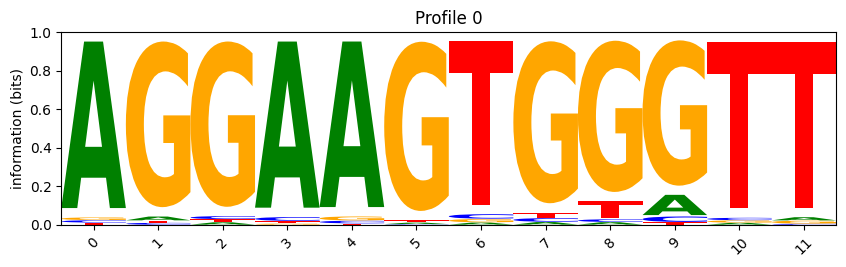

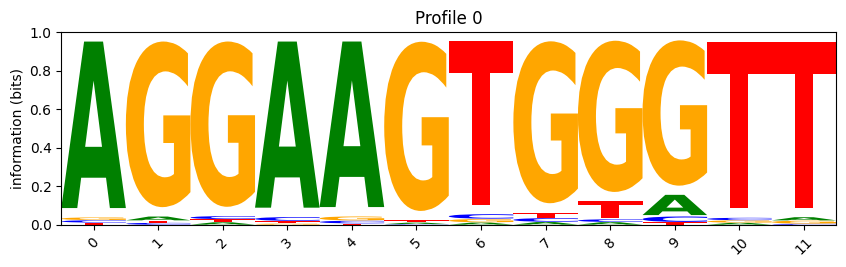

In [112]:
plotting.plotLogo(dbg_model.getP(), dbg_setup.data.alphabet)
plotting.plotLogo(dbg_model_legacy.getP(), dbg_setup.data.alphabet)

There are tiny numerical differences in the gradients, but I'm not convinced that this is the reason for the diverging parameters.

Next: do a barebone implementation of the two different training methods, without using any model, and compare the gradients, losses and results.

In [10]:
def _getQ_scan(X, Q, window_size):
    assert X.shape == (1, 1, 2, 2, len(dbg_seq), 4), f"Expected shape (1, 1, 2, 2, ts, 4), got {X.shape=}" # (B, ntiles, N, f, ts, alphabet)
    assert Q.shape == (1, 4), f"Expected shape (1, 4), got {Q.shape=}" # (1, alphabet_size)
    
    batch_dims = 4 # number of batch dimensions, e.g. 4 for (batch_size, ntiles, N, f, tile_size)+(alphabet_size,)*(order+1)
    Q1 = tf.reshape(Q, ((1,)*batch_dims)+(1,)+Q.shape) # shape: (         1,      1, 1, 1,         1, K)+(alphabet_size,)*(order+1)
    X1 = tf.expand_dims(X, -2) #                         shape: (batch_size, ntiles, N, f, tile_size, 1)+(alphabet_size,)*(order+1)
    R = tf.multiply(X1, Q1) # shape: (batch_size, ntiles, N, f, tile_size, K)+(alphabet_size,)*(order+1)
    assert R.shape == X.shape[:5] + Q.shape, \
        f"Expected shape {X.shape[:5] + Q.shape}, got {R.shape}"
    R1 = tf.reduce_sum(R, axis=list(range(-1,0))) # shape: (batch_size, ntiles, N, f, tile_size, K), sum over alphabet_size dimensions
    
    # at this point, each kmer in X was multiplied with Q and the result is in R1
    # now we need to slide the window over the tile_size dimension
    # luckily, tensorflow has this built-in
    S = tftext.sliding_window(data=R1, width=window_size, axis=-2) # shape: (batch_size, ntiles, N, f, tile_size-width+1, width, K)
    # logging.debug(f"[background_model.scan_data] >>> S shape after sliding window: {S.shape}")
    S = tf.reduce_sum(S, axis=-2) # shape: (batch_size, ntiles, N, f, tile_size-width+1, K), sum over new width dimension
    # logging.debug(f"[background_model.scan_data] >>> S shape after sum: {S.shape}")
    assert S.shape[-2:] == (len(dbg_seq) - window_size + 1, 1), \
        f"Expected ({len(dbg_seq) - window_size + 1}, {1}) in scores, got {S.shape}"

    # we're only interested in the best model match at each position, so we take the max over the last dimension
    S = tf.reduce_max(S, axis=-1, keepdims=True) # shape: (batch_size, ntiles, N, f, tile_size-width+1, 1)
    return S


def _getZ_new(X, P, Q, epsilon=1e-6):
    """
    Compute the Z matrix for the new implementation.
    """
    P = tf.math.log(tf.maximum(P, epsilon)) # avoid log(0)
    X1 = tf.expand_dims(X,-1) # 1 input channel   shape: (B, ntiles, N, f, tile_size, alphabet_size, 1)
    P1 = tf.expand_dims(P,-2) # 1 input channel   shape: (k, alphabet_size, 1, U)
    
    # X1: (batch_shape (B, ntiles, N, f), in_height (tile_size),     in_width (alphabet_size), in_channels (1))
    # P1:                                (    filter_height (k), filter_width (alphabet_size), in_channels (1), out_channels (U))
    # Z1: (batch_shape (B, ntiles, N, f), tile_size-k+1, 1, U)
    Z1 = tf.nn.conv2d(X1, P1, strides=1, padding='VALID', data_format="NHWC", name="Z")
    Z_P = tf.squeeze(Z1, -2) # remove input channel dimension   shape (B, ntiles, N, f, tile_size-k+1, U)
    Q_scan = _getQ_scan(X, Q, P.shape[0])  # shape (B, ntiles, N, f, tile_size-k+1, 1)
    Z = Z_P - Q_scan # shape (B, ntiles, N, f, tile_size-k+1, U)
    return Z


def _getZ_legacy(X, P, Q, epsilon=1e-6):
    assert Q.shape == (4,), f"Expected shape (4,), got {Q.shape=}" # (1, alphabet_size)
    Q = tf.maximum(Q, epsilon) # avoid division by 0 TODO: is this sensible?
    Q1 = tf.expand_dims(Q, 0)
    Q2 = tf.expand_dims(Q1, -1)
    # Limit the odds-ratio, to prevent problem with log(0).
    # Very bad matches of profiles are irrelevant anyways.
    ratio = tf.maximum(P/Q2, epsilon)
    R = tf.math.log(ratio)

    X1 = tf.expand_dims(X,-1) # 1 input channel   shape: (ntiles, N, 6, tile_size, alphabet_size, 1)
    R1 = tf.expand_dims(R,-2) # 1 input channel   shape: (k, alphabet_size, 1, U)

    # X1: (batch_shape (B, ntiles, N, 6), in_height (tile_size),     in_width (alphabet_size), in_channels (1))
    # R1:                                (    filter_height (k), filter_width (alphabet_size), in_channels (1), out_channels (U))
    # Z1: (batch_shape (B, ntiles, N, 6), tile_size-k+1, 1, U)
    Z1 = tf.nn.conv2d(X1, R1, strides=1, padding='VALID', data_format="NHWC", name="Z")
    Z = tf.squeeze(Z1, -2) # remove input channel dimension   shape (ntiles, N, 6, tile_size-k+1, U)
    return Z


def _call(X, P, Q, legacy_Z=False):
    if legacy_Z:
        Z = _getZ_legacy(X, P, Q[0])
    else:
        Z = _getZ_new(X, P, Q)
        
    S = tf.reduce_max(Z, axis=[-3,-2])   # shape (B, ntiles, N, U)
    return S, Z


def _lossfun(Z, P_logit):
    # shape of Z: B x ntiles x N x f x tile_size-k+1 x U 
    assert Z.shape == (1, 1, 2, 2, len(dbg_seq)-P_logit.shape[0]+1, 1), f"{Z.shape=}, expected shape (B, ntiles, N, f, tile_size-k+1, U)"
    S = tf.reduce_max(Z, axis=[0,1,3,4]) # N x U
    score = tf.reduce_sum(S)
    
    Z = tf.transpose(Z, [2,5,0,1,3,4]) # shape N x U x B x ntiles x f x tile_size-k+1
    Z = tf.reshape(Z, [Z.shape[0], Z.shape[1], -1]) # shape N x U x -1
    Zsm = tf.nn.softmax(1.0*Z, axis=-1) # softmax for each profile in each genome 
    Z = tf.math.multiply(Z, Zsm)
    Z = tf.maximum(Z, 0)
    loss_by_unit = -tf.math.reduce_max(Z, axis=-1) # best isolated match for each profile in each genome (N x U)
    
    def mellowmax(x, a):
        """ See https://en.wikipedia.org/wiki/Smooth_maximum#Mellowmax
            mm(x, a) = 1/a log( sum(exp(x*a)) / n ) --> ( log(sum(exp(x*a))) - log(n) ) / a 
            (according to https://stackoverflow.com/a/76608729 to avoid possible overflow)

        x should have shape (N, U)
        """
        # logging.debug(f"[model.lossfun] >>> mellowmax called with {x.shape=} and {a=}")
        n = x.shape[0] # N
        x = tf.math.multiply(x, a) # (N, U)
        lse = tf.math.log(tf.reduce_sum(tf.exp(x), axis=0)) # (U)
        return tf.math.divide(tf.math.subtract(lse, tf.math.log(tf.cast(n, x.dtype))), a)

    loss_by_unit = mellowmax(loss_by_unit, 1.0)
    L2 = tf.reduce_sum(tf.math.square(P_logit), axis=[0,1]) # U
    L2 = tf.math.divide(L2, P_logit.shape[0])
    L2 = tf.math.multiply(L2, 0.1)
    loss_by_unit = tf.math.add(loss_by_unit, L2)      # U
    return score, loss_by_unit


@tf.function()
def _train_step(X, P_logit, Q, opt, legacy_Z: bool):
    P = tf.nn.softmax(P_logit, axis=1)
    with tf.GradientTape() as tape:
        S, Z = _call(X, P, Q, legacy_Z)
        score, loss_by_unit = _lossfun(Z, P_logit)
        loss = tf.reduce_sum(loss_by_unit)
        
    grad = tape.gradient(loss, P_logit)
    opt.apply_gradients([(grad, P_logit)])

    return S, loss, P_logit, grad

In [11]:
# Compute the order of magnitude of the difference to scale it between 1 and 10
def scale_to_1_10(arr):
    arr = np.abs(arr)
    max_val = np.max(arr)
    if max_val == 0:
        return np.zeros_like(arr), 0
    exponent = int(np.floor(np.log10(max_val)))
    factor = 10 ** (-exponent)
    scaled = arr * factor
    return scaled, factor

In [14]:
dbg_seq = genomes[0].getSequenceStrings()[0][:17]  # Use a shorter sequence for debugging

dbg_genome = SequenceRepresentation.Genome([SequenceRepresentation.Sequence('dbg', 'cho0', '+', 0, sequence=dbg_seq)])
dbg_genomes = [dbg_genome, dbg_genome] # otherwise error: need at least two genomes for training
dbg_data = ModelDataSet.ModelDataSet(dbg_genomes, ModelDataSet.DataMode.DNA, tile_size=len(dbg_seq), tiles_per_X=1, batch_size=1, prefetch=1)

Xfwd = utils.oneHot(dbg_seq, dbg_data.alphabet)
Xrc = utils.oneHot(dbg_seq[::-1].translate(utils._rctbl), dbg_data.alphabet)
X0 = np.stack([Xfwd, Xrc], axis=0, dtype=np.float32)  # shape
X1 = X0.copy()
X = np.stack([X0, X1], axis=0)
# bring X to shape (B, ntiles, N=2, f=2, 12, 4) where B, ntiles are 1
X = X.reshape((1, 1, 2, 2, len(dbg_seq), 4))
print(f"{X.shape=}")

Q = np.array([[0.2, 0.3, 0.3, 0.2]], dtype=np.float32)
print(f"{Q.shape=}")
P_logit_init = np.random.normal(size=(12, 4, 1), loc=0.0, scale=1.0).astype(np.float32)
P_logit_new = tf.Variable(P_logit_init.copy(), trainable=True, name="P_logit_new")
P_logit_legacy = tf.Variable(P_logit_init.copy(), trainable=True, name="P_logit_legacy")
print(f"{P_logit_init.shape=}")

opt_new = tf.keras.optimizers.Adam(learning_rate=2.0)
opt_legacy = tf.keras.optimizers.Adam(learning_rate=2.0)

X.shape=(1, 1, 2, 2, 17, 4)
Q.shape=(1, 4)
P_logit_init.shape=(12, 4, 1)


In [15]:
for epoch in range(10):
    print(f"Epoch {epoch+1}")
    
    S_new, loss_new, P_logit_new, grad_new = _train_step(X, P_logit_new, Q, opt_new, legacy_Z=False)
    S_legacy, loss_legacy, P_logit_legacy, grad_legacy = _train_step(X, P_logit_legacy, Q, opt_legacy, legacy_Z=True)
    print(f"Epoch {epoch+1}:")
    S_diff, S_diff_factor = scale_to_1_10(S_new.numpy() - S_legacy.numpy())
    loss_diff, loss_diff_factor = scale_to_1_10(loss_new.numpy() - loss_legacy.numpy())
    grad_diff, grad_diff_factor = scale_to_1_10(grad_new.numpy() - grad_legacy.numpy())
    P_logit_diff, P_logit_diff_factor = scale_to_1_10(P_logit_new.numpy() - P_logit_legacy.numpy())
    print(f"  Differences in S: {S_diff[0,0,0,0]}, factor: {S_diff_factor}")
    print(f"  Differences in loss: {loss_diff}, factor: {loss_diff_factor}")
    print(f"  Differences in grad: {grad_diff[0]}, factor: {grad_diff_factor}")
    print(f"  Differences in P_logit: {P_logit_diff[0]}, factor: {P_logit_diff_factor}")
    print("----------------------------")

Epoch 1
Epoch 1:
  Differences in S: 1.9226839542388916, factor: 0.1
  Differences in loss: 0.0, factor: 0
  Differences in grad: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
  Differences in P_logit: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
----------------------------
Epoch 2
Epoch 2:
  Differences in S: 1.8964070081710815, factor: 0.1
  Differences in loss: 0.0, factor: 0
  Differences in grad: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
  Differences in P_logit: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
----------------------------
Epoch 3
Epoch 3:
  Differences in S: 1.8964067697525024, factor: 0.1
  Differences in loss: 9.814107418060303, factor: 100
  Differences in grad: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
  Differences in P_logit: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
----------------------------
Epoch 4
Epoch 4:
  Differences in S: 1.8964070081710815, factor: 0.1
  Differences in loss: 5.603218078613281, factor: 100
  Differences in grad: [[0.]
 [0.]
 [0.]
 [0.]], factor: 0
  Differences in P_logit: [[0.]

Investigate `_call()`, `S` yields different results that seem to be more than just numerical issues.

In [16]:
Q = np.array([[0.2, 0.3, 0.3, 0.2]], dtype=np.float32)
P_logit = np.random.normal(size=(12, 4, 1), loc=0.0, scale=1.0).astype(np.float32)
P = tf.nn.softmax(P_logit, axis=1)

In [17]:
S_new, Z_new = _call(X, P, Q, legacy_Z=False)
S_legacy, Z_legacy = _call(X, P, Q, legacy_Z=True)

In [18]:
S_diff, S_diff_factor = scale_to_1_10(S_new.numpy() - S_legacy.numpy())
Z_diff, Z_diff_factor = scale_to_1_10(Z_new.numpy() - Z_legacy.numpy())
print(f"S_new: {S_new.numpy()[0,0,0,0]}, S_legacy: {S_legacy.numpy()[0,0,0,0]}")
print(f"Differences in S: {S_diff[0,0,0,0]}, factor: {S_diff_factor}")
print(f"Z_new: {Z_new.numpy()[0,0,0,0]}, Z_legacy: {Z_legacy.numpy()[0,0,0,0]}")
print(f"Differences in Z: {Z_diff[0,0,0,0]}, factor: {Z_diff_factor}")

S_new: -18.790401458740234, S_legacy: 0.17366790771484375
Differences in S: 1.8964070081710815, factor: 0.1
Z_new: [[-22.6808]
 [-18.7904]
 [-23.7268]
 [-19.1386]
 [-22.3239]
 [-28.6563]], Z_legacy: [[-3.7167]
 [ 0.1737]
 [-4.7627]
 [-0.1745]
 [-3.3599]
 [-9.3868]]
Differences in Z: [[1.8964]
 [1.8964]
 [1.8964]
 [1.8964]
 [1.8964]
 [1.927 ]], factor: 0.1


Does this also happen in the model?

In [22]:
dbg_bgmodel = background_model.TrainedQ(dbg_data, num_models=1, order=0, rand_seed=SEED) # no need to train
dbg_bgmodel.Q_logit = tf.Variable(np.log(Q), trainable=True)

dbg_setup = ProfileFindingSetup.ProfileFindingTrainingSetup(
    data=dbg_data,
    U=1, k=12, midK=8, s=0,
    epochs=200, gamma=1.0, l2=0.1, kld=0.0, mellowmax_alpha=1.0,
    match_score_factor=0.7, learning_rate=2.0, lr_patience=5, lr_factor=0.75,
    rho=0.0, sigma=1.0, profile_plateau=10, profile_plateau_dev=150,
    n_best_profiles=2,
    phylo_t=0.0,
    Q_order=0, Q_num_models=1, Q_learning_rate=0.01, Q_lr_patience=10, Q_lr_factor=0.75, Q_epochs=50, Q_rand_seed=SEED,
    Q = dbg_bgmodel,
)

tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models

dbg_model = model.SpecificProfile(dbg_setup, rand_seed=SEED)

S_new, _, Z_new = dbg_model.call(X, dbg_model.getP())
dbg_model.legacy_Z = True
S_legacy, _, Z_legacy = dbg_model.call(X, dbg_model.getP())

S_diff, S_diff_factor = scale_to_1_10(S_new.numpy() - S_legacy.numpy())
Z_diff, Z_diff_factor = scale_to_1_10(Z_new.numpy() - Z_legacy.numpy())
print(f"S_new: {S_new.numpy()[0,0,0,0]}, S_legacy: {S_legacy.numpy()[0,0,0,0]}")
print(f"Differences in S: {S_diff[0,0,0,0]}, factor: {S_diff_factor}")
print(f"Z_new: {Z_new.numpy()[0,0,0,0]}, Z_legacy: {Z_legacy.numpy()[0,0,0,0]}")
print(f"Differences in Z: {Z_diff[0,0,0,0]}, factor: {Z_diff_factor}")

2025-08-07 16:38:07,915 - DEBUG - [TrainedQ.__init__] >>> setting tf global seed to 42
2025-08-07 16:38:07,932 - DEBUG - [background_model.__init__] >>> Q_logit shape: (1, 4), m_logit shape: (1,)
2025-08-07 16:38:08,226 - DEBUG - [model.__init__] >>> setting tf global seed to 42


S_new: -12.455175399780273, S_legacy: -12.45517349243164
Differences in S: 1.9073486328125, factor: 1000000
Z_new: [[-33.0661]
 [-33.1004]
 [-36.4462]
 [-36.5351]
 [-19.3985]
 [-33.7222]], Z_legacy: [[-33.0661]
 [-33.1004]
 [-36.4462]
 [-36.5351]
 [-19.3985]
 [-33.7222]]
Differences in Z: [[3.8147]
 [3.8147]
 [0.    ]
 [3.8147]
 [0.    ]
 [0.    ]], factor: 1000000


/home/matthis/PhD/genomegraph/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-08-07 16:38:08.316226: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [38]:
# np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability
np.set_printoptions(precision=10, suppress=True) # Suppress scientific notation for small numbers for better readability

In [45]:
def cut_float_digits(x, num_digits):
  """
  Cuts a float value to a specified number of digits after the decimal point.

  Args:
    x: A TensorFlow tensor (float or int).
    num_digits: The number of digits to keep after the decimal point.

  Returns:
    A TensorFlow tensor with the float values cut to the specified number of digits.
  """
  factor = tf.pow(10.0, tf.cast(num_digits, tf.float32))
  truncated = tf.floor(tf.multiply(x, factor)) / factor
  return truncated

# Example usage
x = tf.constant([100.123456789, 0.123454321, 1.23456789])
num_digits = 7
cut_float_digits(x, num_digits)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([100.12346  ,   0.1234543,   1.2345679], dtype=float32)>

---

In [ ]:
legacy_model.train()

In [ ]:
plotting.plotHistory(legacy_model.history)

In [ ]:
plotting.plotLogo(legacy_model.profile_report.P, data.alphabet)

In [ ]:
tf.keras.backend.clear_session() # avoid memory cluttering by remains of old models
new_model = model.SpecificProfile(setup, rand_seed=SEED)
new_model.train()

In [ ]:
plotting.plotHistory(new_model.history)

In [ ]:
plotting.plotLogo(new_model.profile_report.P, data.alphabet)

---

In [ ]:
def from_one_hot(X, k):
    """Convert one-hot encoded tensor to string representation."""
    import itertools
    alphabet = [''.join(p) for p in itertools.product([c for c in 'ACGT'], repeat=k)]
    assert X.shape[-1] == 4**k, "Last dimension must match 4^k for k-mer encoding"
    assert len(X.shape) == 6, "Input tensor must be 6D: (batch_size, tiles_per_X, N, f, tile_size, alphabet_size)"
    for b in range(X.shape[0]):
        for t in range(X.shape[1]):
            for n in range(X.shape[2]):
                for f in range(X.shape[3]):
                    oh = X[b, t, n, f, :, :]
                    idcs = [np.argmax(oh[j,:]) if np.max(oh[j,:]) != 0 else -1 \
                            for j in range(oh.shape[0])]
                    seq = ' '.join([ alphabet[i] if i != -1 else 'N' for i in idcs ])
                    print(f"Batch {b}, Tile {t}, Sequence {n}, Frame {f}: {seq}")
    #return ''.join(['ACGT'[np.argmax(x)] for x in X])

In [ ]:
# quick test of k-mer dataset
raw_data = [
    'ACGT',
    'AACCGGTT',
    'TAACGTAG'
]
data = ModelDataSet.ModelDataSet(
    [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=s)]) \
                                   for i, s in enumerate(raw_data)],
    ModelDataSet.DataMode.DNA,
    tile_size=8,
    tiles_per_X=1,
    batch_size=1,
    prefetch=1,
)

ds = data.getDataset(k=1)
for X, _ in ds:
    assert X.shape == (1,1,3,2,8,4)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 1)
    break

In [ ]:
ds = data.getDataset(k=2)
for X, _ in ds:
    assert X.shape == (1,1,3,2,7,16), f"Expected shape {(1,1,2,2,7,16)}, got {X.shape}"  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X, 2)  # Convert to string representation
    break

In [ ]:
ds = data.getDataset(k=3)
for X, _ in ds:
    assert X.shape == (1,1,3,2,6,64)  # (batch_size, tiles_per_X, len(raw_data), frames, tile_size, alphabet_size)
    print(X.shape)
    print(X[0, 0, :, 0, :, :].numpy())  # Print the first tile, first frame
    from_one_hot(X.numpy(), 3)  # Convert to string representation
    break

---

In [ ]:
N = 1000
seqlen = 100
tile_size = 100
batch_size = 1# 32
K = 1

In [ ]:
def generate_data(model: np.ndarray, N: int, seqlen: int, tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = np.zeros(len(alphabet), dtype=int)
    for seq in raw_data:
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = counts / np.sum(counts)
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data: {relative_frequencies}")
            
    return data, relative_frequencies

In [ ]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [ ]:
def single_model_test(ground_truth: np.ndarray, name: str, lr: float = 0.1, epochs: int = 50,
                      N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, batch_size: int = batch_size, 
                      K: int = 1, perfect_initialization: bool = False):
    """ 
    K: since there is only one ground truth, by default learn only one model. However, it might make sense to learn
       two models for unbalanced ground truths, as the data contains both the fwd and rc sequences which will have
       opposing distributions. In this case, try setting K to 2.
    perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    logging.info(f"Testing model {name} with parameters: {ground_truth} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_data(ground_truth, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        assert K == 1, f"[single_model_test] perfect_initialization is not supported with {K=} != 1"
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.expand_dims(np.log(relative_frequencies), 0))
        model.m_logit.assign([1.0])  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init},\n\nTrained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init},\n\nTrained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")

In [ ]:
single_model_test(ground_truth_1, "Uniform Distribution")

In [ ]:
single_model_test(ground_truth_1, "Uniform Distribution perfect init", lr=0.01, perfect_initialization=True)

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1", lr=5)

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 1 perfect init", lr=0.01, perfect_initialization=True)

Vermutung: Verteilung `[A: 0.1, C: 0.2, G: 0.3, T: 0.4]` wird nicht gelernt, da das in den RC-Sequenzen zu 
`[A: 0.4, C: 0.3, G: 0.2, T: 0.1]` führt. Bei asymmetrischen Verteilungen könnten aber zwei zu lernende Modelle mit 
gleichen Gewichten funktionieren

In [ ]:
single_model_test(ground_truth_2, "Non-Uniform Distribution 2, v2", lr=0.1, epochs=50, N=1000, seqlen=100, batch_size=1, K=2)

In [ ]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2")

In [ ]:
single_model_test(ground_truth_3, "Non-Uniform Distribution 2 perfect init", lr=0.01, perfect_initialization=True)

---

In [ ]:
def generate_mixed_data(models: list[np.ndarray], weights: list[float], N: int, seqlen: int, tile_size: int, 
                        batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(models) == len(weights), "Number of models must match number of weights."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    for model in models:
        assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    raw_data = []
    chosen_models = []
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(len(models)), weights=weights, k=1)[0]
        model = models[mi]
        # Generate a sequence using the chosen model
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        raw_data.append(seq_str)
        chosen_models.append(mi)

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
               for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    # count the relative frequencies of the nucleotides in the generated sequences for verification
    counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
    for i, seq in enumerate(raw_data):
        mi = chosen_models[i]
        for c in seq:
            assert c in alphabet, \
                f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
            ci = alphabet.index(c)
            counts[mi][ci] += 1

    # Calculate the relative frequencies
    relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
    logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
            
    return data, relative_frequencies

In [ ]:
def multi_model_test(ground_truths: list[np.ndarray], weights: list[float], name: str, 
                     lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                     batch_size: int = batch_size, K: int = None, perfect_initialization: bool = False):
    """ perfect_initialization: If True, initializes the model with the relative nt frequencies of the data. """
    assert len(ground_truths) >= 1, "At least one ground truth model is required for multi-model testing."
    assert len(ground_truths) == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = len(ground_truths)
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_mixed_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    model = background_model.TrainedQ(data, num_models=K, order=0, rand_seed=SEED)

    if perfect_initialization:
        # Initialize the model with the relative frequencies of the nucleotides in the generated data
        model.Q_logit.assign(np.log(np.array(relative_frequencies)))
        model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Relative frequencies of nucleotides in generated data:\n{relative_frequencies}\n\nwith weights:\n{weights}")

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_3], [0.3, 0.7], "Mixed Model 2", 
                 lr=0.1, epochs=75, N=1000, seqlen=100, batch_size=1)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1 perfect init", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, perfect_initialization=True)

In [ ]:
multi_model_test([ground_truth_1, ground_truth_2, ground_truth_3], [0.2, 0.3, 0.5], "Mixed Model 1, higher K", 
                 lr=0.01, epochs=75, N=1000, seqlen=100, batch_size=1, K=4)

---

In [ ]:
import importlib
importlib.reload(background_model)

In [ ]:
def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
                               tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert len(model.shape) >= 2, \
        "Model must be a >=2D array for multiple higher order Markov models. First dimension is K (number of models), "\
        + f"the remaining `order+1` dimensions are 4. Got shape: {model.shape}."
    num_models = model.shape[0]  # number of models
    size = len(alphabet)
    assert model.shape[1:] == (size,)*(len(model.shape)-1), \
        f"Model must be a higher order Markov model with ({size})^k rows for some int k, but got shape {model.shape}."
    assert len(weights) == num_models, \
        f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
            + f"Got {len(weights)}."
    assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
    k = len(model.shape) - 1  
    j = k - 1 # order of the Markov model
    assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
    assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
    
    # # reshape the model to a (4^(j), 4, K) array -> j-mers, ACGT, models
    # dense_model = model.reshape((4**(j), 4, num_models))
    # # check that the model is normalized
    # for mi in range(2):
    #     assert np.allclose(np.sum(dense_model[:,:,mi], axis=1), 1.0), \
    #         f"Model {mi} is not normalized. Sum of probabilities: {np.sum(dense_model[:,:,mi], axis=1)}"
    
    mod_sums = np.expand_dims( np.sum(model, axis=tuple(list(range(1,k+1)))), -1 )
    freqs = model.reshape((num_models, size**k)) / mod_sums # normalized, sum to 1
    assert np.allclose(np.sum(freqs, axis=1), 1.0), \
        f"Model frequencies are not normalized. Sum of probabilities: {np.sum(freqs, axis=1)}" # should not happen
    
    # start data generation
    raw_data = []
    chosen_models = []
    kmer_freqs = [{kmer: 0 for kmer in [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)]} \
                  for _ in range(num_models)]  # to store k-mer frequencies for each model
    for _ in range(N):
        # Choose a model based on the weights
        mi = random.choices(range(num_models), weights=weights, k=1)[0]
        chosen_models.append(mi)
        start_kmer_idx = random.choices(range(4**k), weights=freqs[mi, :], k=1)[0]
        idx_seq = list(np.unravel_index(start_kmer_idx, (size,)*k))  # Start with a random k-mer
        for i in range(k, seqlen): # Generate the rest of the sequence
            # Get the last j characters to determine the next character
            jmer_idcs = idx_seq[i-j:i]  # last j characters
            next_idx = random.choices(range(size), weights=model[(mi,)+tuple(jmer_idcs)], k=1)[0]
            idx_seq.append(next_idx)  # Append the next character index

        assert len(idx_seq) == seqlen, \
            f"Generated sequence length {len(idx_seq)} does not match expected length {seqlen}."
            
        # Convert the index sequence to a string
        seq = ''.join([alphabet[i] for i in idx_seq])

        # Update k-mer frequencies for the chosen model
        for i in range(seqlen - k + 1):
            kmer = seq[i:i+k]
            assert kmer in kmer_freqs[mi], \
                f"Generated k-mer {kmer} not in model alphabet {alphabet}." # should not happen
            kmer_freqs[mi][kmer] += 1

        # Append the sequence to the data list
        raw_data.append(seq)

    # Normalize k-mer frequencies
    for mi in range(num_models):
        total_count = sum(kmer_freqs[mi].values())
        if total_count > 0:
            for kmer in kmer_freqs[mi]:
                kmer_freqs[mi][kmer] /= total_count
        else:
            logging.warning(f"Model {mi} has no k-mers generated. Frequencies will be zero.")

    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
                                                                              source=f"model {chosen_models[i]}")]) \
                for i, seq in enumerate(raw_data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
    assert ''.join(data.alphabet) == "ACGT", \
        f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
    logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

    return data, kmer_freqs

In [ ]:
import importlib
importlib.reload(background_model)

In [ ]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    print(f"=== Order {order} ===")
    print("Comparing generated k-mer frequencies with expected model frequencies:")
    print()
    print("K-mer || gen. m0 | exp. m0 |   diff || gen. m1 | exp. m1 |   diff")
    print("------++---------+---------+--------++---------+---------+-------")
    for kmer in data_kmer_freqs[0]:
        print(f" {' '*(4-k)}{kmer} ||  {data_kmer_freqs[0][kmer]:.4f} |  {freqs[0][kmer]:.4f} | {abs(data_kmer_freqs[0][kmer]-freqs[0][kmer]):.4f} ||  {data_kmer_freqs[1][kmer]:.4f} |  {freqs[1][kmer]:.4f} | {abs(data_kmer_freqs[1][kmer]-freqs[1][kmer]):.4f}")

    print()


In [ ]:
for order in [0, 1, 2]:
    model0, freqs0, alphabet = background_model.get_background_model(order=order, model_type="uniform")
    model1, freqs1, alphabet = background_model.get_background_model(order=order, model_type="random", seed=SEED)
    # model = np.zeros(model0.shape+(2,))
    # model[:, :, :, 0] = model0
    # model[:, :, :, 1] = model1
    k = len(model0.shape)
    model = np.array([model0, model1])#.transpose(tuple(range(1,k+1))+(0,))
    freqs = [freqs0, freqs1]
    weights = [0.5, 0.5]
    print(model.shape)

    data, data_kmer_freqs = generate_higher_order_data(model, weights, N, seqlen=1000, 
                                                       tile_size=tile_size, batch_size=batch_size, alphabet=alphabet)

    # reconstruct the model from the data
    model_reconstructed = np.zeros(model.shape)
    for mi in range(model.shape[0]):
        for i, (kmer, freq) in enumerate(data_kmer_freqs[mi].items()):
            kmer_idx = np.unravel_index(i, (len(alphabet),)*k)
            # print(f"[DEBUG] Reconstructing k-mer {kmer} with frequency {freq} for model {mi} | model shape {model_reconstructed.shape} | kmer index in model {kmer_idx}")
            model_reconstructed[(mi,)+kmer_idx] = freq

    # normalize the models
    model_reconstructed /= np.sum(model_reconstructed, axis=-1, keepdims=True)

    print(f"=== Order {order} Reconstructed ===")
    print(f"Ground Truth Model:\n{model[0]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[0]}\n")
    print(f"Difference:\n{np.abs(model[0] - model_reconstructed[0])}\n")
    print(f"Ground Truth Model:\n{model[1]}\n")
    print(f"Reconstructed Model:\n{model_reconstructed[1]}\n")
    print(f"Difference:\n{np.abs(model[1] - model_reconstructed[1])}\n")
    print()


In [ ]:
def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
                            lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
                            batch_size: int = batch_size):
    """ K: manually set the number of learned models, otherwise defaults to the number of ground_truths models """
    assert len(ground_truths.shape) >= 2, \
        f"ground_truths must be of shape (K,)+(4)*k for some k>0. Got {ground_truths.shape}"
    assert ground_truths.shape[0] == len(weights), "Number of ground truth models must match number of weights."
    if K is None:
        K = ground_truths.shape[0]
    else:
        assert K >= 1, f"Need to train at least one model, got {K=}"
    logging.info(f"Testing model {name} with parameters: {ground_truths} " \
                 + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
    data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
    k_dims = len(ground_truths.shape) - 1
    order = k_dims - 1
    model = background_model.TrainedQ(data, num_models=K, order=order, rand_seed=SEED)

    # not implemented yet
    # if perfect_initialization:
    #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
    #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
    #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

    # get initial model parameters
    Q_init_raw = model.Q_logit.numpy()
    Q_init = model.getQ().numpy()
    m_init_raw = model.m_logit.numpy()
    m_init = model.getM().numpy()
    
    # Fit the background model
    losses = model.train(lr, epochs)

    # plot losses
    plt.plot(losses, label=f'Losses for Model {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training Loss for {name}')
    plt.legend()
    plt.show()

    # Get the trained model parameters
    Q_trained_raw = model.Q_logit.numpy()
    Q_trained = model.getQ().numpy()
    m_trained_raw = model.m_logit.numpy()
    m_trained = model.getM().numpy()

    logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
    logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
    logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
    logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
    logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

    return model, losses, data, relative_frequencies

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
ground_truth_higher_order = np.array([model0])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, uniform",
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model1])
weights = [1]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 1 model, random", K=2,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model0, freqs0, alphabet = background_model.get_background_model(order=1, model_type="uniform")
model1, freqs1, alphabet = background_model.get_background_model(order=1, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model0, model1])
weights = [0.3, 0.7]
_, _, _, _ = higher_order_model_test(ground_truth_higher_order, weights, "First order, 2 models", K=3,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

In [ ]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

```
Ground truth of generated data:         Model 0                            Model 1
    [[[[0.141  0.358  0.2756 0.2254]    [[[0.1438 0.3566 0.2776 0.2221]    [[[0.203  0.4977 0.1695 0.1298]
       [0.1262 0.1262 0.047  0.7006]      [0.1166 0.116  0.0429 0.7246]      [0.4409 0.0779 0.1324 0.3487]
       [0.2614 0.3079 0.009  0.4218]      [0.26   0.3105 0.0062 0.4233]      [0.1885 0.2565 0.1034 0.4516]
       [0.5904 0.1506 0.129  0.1301]]     [0.5912 0.1584 0.1257 0.1247]]     [0.5045 0.2135 0.1448 0.1372]]

      [[0.196  0.3381 0.2783 0.1876]     [[0.1933 0.341  0.2802 0.1856]     [[0.3039 0.2027 0.4079 0.0855]
       [0.434  0.0989 0.2072 0.2599]      [0.4332 0.0942 0.2077 0.2649]      [0.4899 0.0201 0.4335 0.0565]
       [0.2333 0.4016 0.1021 0.263 ]      [0.2392 0.4019 0.0955 0.2634]      [0.2009 0.6322 0.1244 0.0424]
       [0.4181 0.0328 0.4288 0.1203]]     [0.4193 0.0308 0.4237 0.1262]]     [0.4905 0.2051 0.1703 0.134 ]]

      [[0.0233 0.3404 0.3464 0.29  ]     [[0.0174 0.3389 0.356  0.2877]     [[0.1573 0.6412 0.0439 0.1576]
       [0.1995 0.064  0.4482 0.2883]      [0.1946 0.0706 0.4492 0.2856]      [0.3423 0.0543 0.2795 0.3239]
       [0.0782 0.3172 0.022  0.5826]      [0.0984 0.32   0.0173 0.5643]      [0.4985 0.1611 0.1072 0.2332]
       [0.1476 0.3779 0.1778 0.2967]]     [0.1449 0.3758 0.1804 0.2989]]     [0.1319 0.2965 0.3175 0.2542]]

      [[0.2208 0.0746 0.3915 0.313 ]     [[0.2235 0.0697 0.396  0.3108]     [[0.1309 0.1471 0.3521 0.3699]
       [0.2801 0.2668 0.1783 0.2748]      [0.2825 0.2616 0.1808 0.2752]      [0.2547 0.0161 0.2737 0.4554]
       [0.1351 0.2992 0.069  0.4967]      [0.1371 0.299  0.0767 0.4872]      [0.3093 0.306  0.2427 0.142 ]
       [0.2106 0.147  0.4491 0.1933]]]]   [0.2039 0.1449 0.4571 0.1941]]]    [0.59   0.0231 0.2553 0.1316]]]
```

In [ ]:
importlib.reload(background_model)

In [ ]:
model2, freqs2, alphabet = background_model.get_background_model(order=2, model_type="random", seed=SEED)
ground_truth_higher_order = np.array([model2])
weights = [1]
trained_model, trained_model_losses, training_data, training_data_freqs = higher_order_model_test(
    ground_truth_higher_order, weights, "Second order, 1 model, random", K=2,
    lr=0.1, epochs=5, N=100, seqlen=100, tile_size=100, batch_size=1)

scan = trained_model.scan_data(window_size=10)

In [ ]:
scan.shape

In [ ]:
scan

In [ ]:
assert False, "Stop here"

In [ ]:
# def higher_order_model_test(ground_truths: np.ndarray, weights: list[float], name: str, K: int = None,
#                             lr: float = 0.1, epochs: int = 50, N: int = N, seqlen: int = seqlen, tile_size: int = tile_size, 
#                             batch_size: int = batch_size, perfect_initialization: bool = False):
#     """ double_K: If True, learn twice as many models as in ground_truths, might help with asymmetric distributions
#         ~~perfect_initialization: If True, initializes the model with the relative nt frequencies of the data.~~ """
#     assert len(ground_truths.shape) == 2, f"ground_truths must be a matrix of (4^k, K). Got {ground_truths.shape}"
#     assert ground_truths.shape[1] == len(weights), "Number of ground truth models must match number of weights."
#     if K is None:
#         K = ground_truths.shape[1]
#     else:
#         assert K >= 1, f"Need to train at least one model, got {K=}"
#     logging.info(f"Testing model {name} with parameters: {ground_truths} " \
#                  + f"and hyperparameters {lr=}, {epochs=}, {N=}, {seqlen=}, {tile_size=}, {batch_size=}, {K=}")
    
#     data, relative_frequencies = generate_higher_order_data(ground_truths, weights, N, seqlen, tile_size, batch_size)
#     order = int(np.log2(ground_truths.shape[0]) / 2) - 1
#     model = background_model.TrainedQ(num_models=K, order=order, rand_seed=SEED)

#     # not implemented yet
#     # if perfect_initialization:
#     #     # Initialize the model with the relative frequencies of the nucleotides in the generated data
#     #     model.Q_logit.assign(np.log(np.array(relative_frequencies).transpose()))
#     #     model.m_logit.assign(np.log(weights))  # Initialize m to 1.0 for simplicity

#     # get initial model parameters
#     Q_init_raw = model.Q_logit.numpy()
#     Q_init = model.getQ().numpy()
#     m_init_raw = model.m_logit.numpy()
#     m_init = model.getM().numpy()
    
#     # Fit the background model
#     losses = model.train(data, lr, epochs)

#     # plot losses
#     plt.plot(losses, label=f'Losses for Model {name}')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title(f'Training Loss for {name}')
#     plt.legend()
#     plt.show()

#     # Get the trained model parameters
#     Q_trained_raw = model.Q_logit.numpy()
#     Q_trained = model.getQ().numpy()
#     m_trained_raw = model.m_logit.numpy()
#     m_trained = model.getM().numpy()

#     logging.info(f"Initial Q (logit/softmax):\n{Q_init_raw}\n\n{Q_init}")
#     logging.info(f"Initial m (logit/softmax):\n{m_init_raw}\n\n{m_init}")
#     logging.info(f"Trained Q (logit/softmax):\n{Q_trained_raw}\n\n{Q_trained}")
#     logging.info(f"Trained m (logit/softmax):\n{m_trained_raw}\n\n{m_trained}")
#     logging.info(f"Ground truth of generated data:\n{ground_truths}\n\nwith weights:\n{weights}")

In [ ]:
# import itertools

# def generate_higher_order_data(model: np.ndarray, weights: list[float], N: int, seqlen: int, 
#                                tile_size: int, batch_size: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
#     assert len(model.shape) == 2, \
#         "Model must be a 2D array for higher order Markov models. First dimension is 4^(order+1), " \
#             + f"second dimension is K (number of models). Got shape: {model.shape}."
#     num_models = model.shape[1]
#     assert len(weights) == num_models, \
#         f"Number of weights must match number of models in the higher order Markov model, which is {num_models}. " \
#             + f"Got {len(weights)}."
#     assert np.isclose(np.sum(weights), 1.0), "Weights must sum to 1."
    
#     # model.shape[0] = 4^k, so k = log4(model.shape[0]) = log2(model.shape[0]) / log2(4) = log2(model.shape[0]) / 2
#     k: float = np.log2(model.shape[0]) / 2
#     assert k.is_integer(), f"Model must be a higher order Markov model with k-mer alphabet. " \
#         + f"Expected 4^k rows for some integer k, but got {model.shape[0]}."
#     assert k >= 1, "Model must be a zero or higher order Markov model with k >= 1."
#     k = int(k)
#     assert seqlen >= k, f"Sequence length must be at least k={k} for higher order Markov models. Got {seqlen}."
#     order = k - 1
#     new_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k)] # 4^k k-mer alphabet
#     assert len(new_alphabet) == 4**k, f"Alphabet size must be 4^k for k={k}, but got {len(new_alphabet)}."

#     # in each column of the model, the 4^k rows correspond to relative k-mer frequencies
#     # to determine the next single character, we need a 0-order model for each k-1-mer
#     jmer_alphabet = [''.join(p) for p in itertools.product([c for c in alphabet], repeat=k-1)] if k > 1 \
#                     else [c for c in alphabet]
#     zero_models = {
#         jmer: model[[new_alphabet.index(jmer + c) for c in alphabet], :] for jmer in jmer_alphabet
#     }
#     # normalize the models to get relative frequencies
#     for jmer in jmer_alphabet:
#         zero_models[jmer] /= np.sum(zero_models[jmer], axis=0, keepdims=True)

#     # Generate random sequences based on the provided models
#     raw_data = []
#     chosen_models = []
#     for _ in range(N):
#         # Choose a model based on the weights
#         mi = random.choices(range(num_models), weights=weights, k=1)[0]
#         init_kmer_idx = random.choices(range(len(new_alphabet)), weights=model[:, mi], k=1)[0]

#         seq = new_alphabet[init_kmer_idx]  # Start with a random k-mer
#         for i in range(k, seqlen-k+1):  # Generate the rest of the sequence
#             # Get the last k-1 characters to determine the next character
#             jmer = seq[i-k+1:i]
#             # Get the zero-order model for this j-mer
#             zero_model = zero_models[jmer][:, mi]
#             # Choose the next character based on the zero-order model
#             next_char = random.choices(alphabet, weights=zero_model, k=1)[0]
#             seq += next_char
        
#         # Append the sequence to the data list
#         raw_data.append(seq)
#         chosen_models.append(mi)

#     # Create a ModelDataSet object with the generated sequences
#     genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq,
#                                                                               source=f"model {chosen_models[i]}")]) \
#                for i, seq in enumerate(raw_data)]
#     data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
#                                      tile_size=tile_size, tiles_per_X=1, batch_size=batch_size, prefetch=1)
#     assert ''.join(data.alphabet) == "ACGT", \
#         f"[generate_data] Alphabet must be ACGT for this model, not {data.alphabet}."
#     logging.debug(f"[generate_data] Steps per epoch: {data.getStepsPerEpoch()}.")

#     # # count the relative frequencies of the nucleotides in the generated sequences for verification
#     # counts = [np.zeros(len(alphabet), dtype=int) for _ in range(len(models))]
#     # for i, seq in enumerate(raw_data):
#     #     mi = chosen_models[i]
#     #     for c in seq:
#     #         assert c in alphabet, \
#     #             f"[generate_data] Sequence contains character {c} not in alphabet {alphabet}." # should not happen
#     #         ci = alphabet.index(c)
#     #         counts[mi][ci] += 1

#     # # Calculate the relative frequencies
#     # relative_frequencies = [counts[mi] / np.sum(counts[mi]) for mi in range(len(models))]
#     # logging.info(f"[generate_data] Relative frequencies of nucleotides in generated data:\n{relative_frequencies}")
#     _, rel_freq, _ = background_model.get_background_model(order=order, model_type="data", src=raw_data)
#     relative_frequencies = np.array([rel_freq[kmer] for kmer in new_alphabet])
#     return data, relative_frequencies

In [ ]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([#[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
              #]).transpose(),
    [1],#[0.3, 0.7],
    N=1000, seqlen=500, tile_size=500, batch_size=1, alphabet="ACGT"
)

print([1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16])
print(relative_frequencies)

In [ ]:
dataset, relative_frequencies = generate_higher_order_data(
    np.array([[1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
              [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose(),
    [0.3, 0.7],
    N=2, seqlen=10, tile_size=10, batch_size=1, alphabet="ACGT"
)

In [ ]:
dataset.getRawData()

In [ ]:
relative_frequencies

In [ ]:
ground_truth_higher_order = np.array([
    [1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16, 1/16],
    [1/16, 2/16, 0.5/16, 0.5/16, 0.1/16, 0.1/16, 0.3/16, 0.5/16, 1.5/16, 2/16, 2/16, 0.25/16, 0.25/16, 2/16, 1/16, 2/16]]).transpose()

higher_order_model_test(ground_truth_higher_order, [0.3, 0.7], "First order, 2 models", K=3,#double_K=True,
                        lr=0.1, epochs=50, N=1000, seqlen=500, tile_size=500, batch_size=1)

---

In [ ]:
np.log(1e-10)